In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub

env: CUPY_ACCELERATORS=cutensor,cub


In [2]:
import tensorly as tl
import plotly.io as pio
#pio.renderers.default = 'iframe'
tl.set_backend('numpy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

TensorLy backend: numpy


In [3]:
from moabb.datasets import *
from moabb.paradigms import MotorImagery
from classification_mi import stf_transform, ZScore
import numpy as np

dataset = AlexMI()
sfreq=250
paradigm = MotorImagery(resample=sfreq, n_classes=2)
epochs, y, meta = paradigm.get_data(dataset, return_epochs=True)
X = epochs.get_data()
groups=meta['subject']

print(X.shape)

select_idc = np.isin(y, ['right_hand', 'rest'])
X = X[select_idc]
y = y[select_idc]
groups = groups[select_idc]

X = stf_transform(X, n_freqs=32, downsample_factor=10)
X = tl.tensor(X)
X.shape

zscore = ZScore()
X = zscore.fit_transform(X)

Choosing from all possible events
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/dataset

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
480 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MiB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


(480, 16, 750)


In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from hoda.classification import SelectFCutoff
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf = make_pipeline(
    FunctionTransformer(tl.to_numpy),
    PCA(n_components=None, whiten=True),
    SelectFCutoff(cutoff=1),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

In [5]:
from sklearn.model_selection import StratifiedGroupKFold
from hoda.classification import BTTDACV
from hoda.hoda import BTTDA

cv = StratifiedGroupKFold(n_splits=5)

hoda_params=  dict(
    max_iter=128,
    toeplitz=(1,),
    taper=False,
    verbose=True,
    refit_shrinkage=True,
)


bttdacv_params = dict(
    hoda_params=hoda_params,
    verbose=True,
    cv=cv,
    n_jobs=-1,
    clf = clf,
)

bttdacv = BTTDACV(
    max_n_blocks=2,
    fixed_n_blocks=True,
    thetas=[0,0.1,0.2,0.3,0.4,0.5,0.6, 0.7, 0.8, 0.9,1],    
    **bttdacv_params
)

    

In [6]:
import joblib
from joblib import Parallel, delayed
import distributed
from hpc import create_cluster, create_client, TIMEOUT


with create_cluster(cluster='wice_sapphirerapids') as cluster, create_client(cluster) as client:
    with joblib.parallel_backend('dask', wait_for_workers_timeout=TIMEOUT): 
        client.wait_for_workers(5*11)
        bttdacv.fit(X,y, groups=groups)



[Parallel(n_jobs=-1)]: Using backend DaskDistributedBackend with 630 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 out of  55 | elapsed:  1.0min remaining:   58.6s
[Parallel(n_jobs=-1)]: Done  55 out of  55 | elapsed:  2.3min finished


Fitting BTTDA with theta=0.7, n_blocks=2
Fitting block 1/2...


Forward model :  61%|██████▏   | 78/127 [00:09<00:06,  7.93it/s]


Fitting block 2/2...


Forward model : 100%|██████████| 127/127 [00:15<00:00,  8.09it/s]


In [7]:
bttdacv.blocks_[0].theta

0.7

In [8]:
bttdacv.blocks_[1].theta

0.7

In [9]:
len(epochs.ch_names)

16

Automatic pdb calling has been turned ON
No baseline correction applied


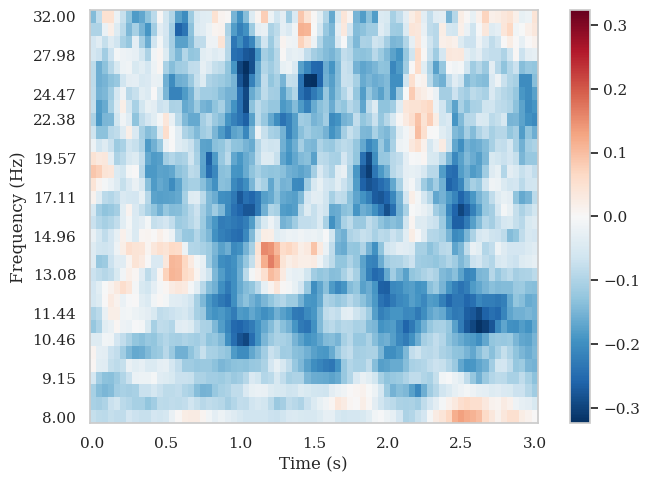

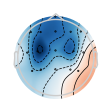

No baseline correction applied


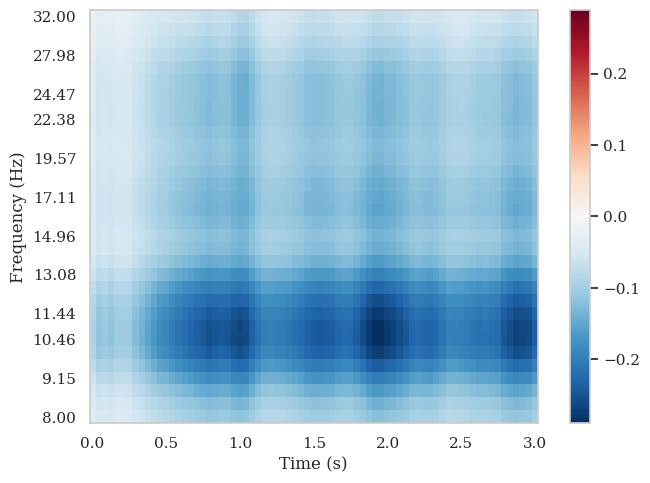

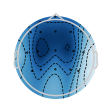

No baseline correction applied


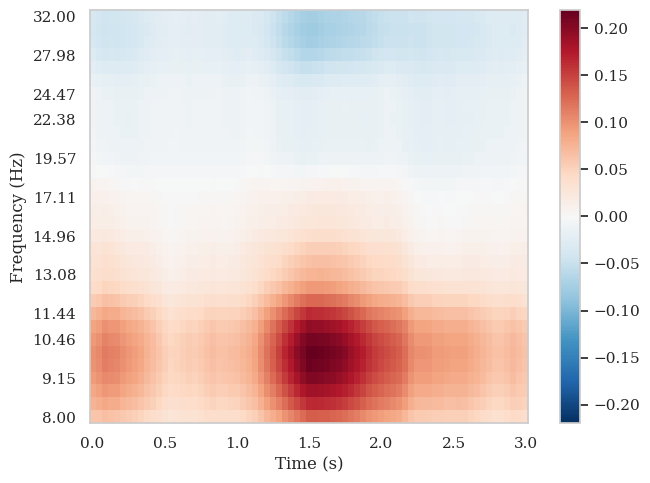

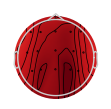

In [19]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import plotly.express as px
from mne.viz import plot_topomap
import seaborn as sns
import matplotlib.pyplot as plt
from mne.time_frequency import EpochsTFRArray
from mne import combine_evoked
from mne.channels import make_standard_montage
%matplotlib inline
%pdb on 
ch_idx = epochs.ch_names.index('C3')
freqs = np.geomspace(8, 32, 32)
times = np.linspace(epochs.times[0], epochs.times[-1], X.shape[-1])

roi = [
    dict(chan='C3', tmin=0.9, tmax=1.1, fmin=9, fmax=14),
    dict(chan='C3', tmin=1.3, tmax=2, fmin=9, fmax=14),
]

def viz_tfr(X, name, chan='C3', **topo_kwargs):    
    X = zscore.inv_transform(X)
    epochs_tfr = EpochsTFRArray(epochs.info, X, times, freqs)
    montage = make_standard_montage('standard_1020')
    epochs_tfr.info.set_montage(montage)

    right_hand = epochs_tfr[y=='right_hand'].average()
    rest = epochs_tfr[y=='rest'].average()
    contrast = combine_evoked([right_hand, rest], weights=[1,-1])
    contrast.save(f'results/interpretability/mi_contrast_{name}_tfr.h5', overwrite=True)

    contrast.copy().pick('C3').plot()
    
    topo = contrast.crop(**topo_kwargs).data.mean(axis=(1,2))
    vlim = np.max(np.abs(topo))
    plot_topomap(topo, epochs.info, vlim=(-vlim, vlim))
    
viz_tfr(X, 'grand-avg')

X_prev = tl.zeros_like(X)
for bi,b in enumerate(bttdacv.blocks_):
    Xt = bttdacv.transform(X, n_blocks=bi+1)
    Xr = bttdacv.inv_transform(Xt, n_blocks=bi+1) - X_prev
    X_prev = Xr
    viz_tfr(Xr, f'block-{bi+1}',**roi[bi])

Xt = bttdacv.transform(X)
Xr = bttdacv.inv_transform(Xt)
#viz_tfr(Xr, 'reconstructed')


In [11]:
epochs.ch_names

['Fpz',
 'F7',
 'F3',
 'Fz',
 'F4',
 'F8',
 'T7',
 'C3',
 'Cz',
 'C4',
 'T8',
 'P7',
 'P3',
 'Pz',
 'P4',
 'P8']